Акт 1 - Підготовка

In [ ]:
!pip install datacollective

ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import librosa
import numpy as np
import os
import random
import kagglehub
from google.colab import drive
from pydub import AudioSegment
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Mounted at /content/drive


In [ ]:
ds_path = kagglehub.dataset_download("neehakurelli/google-speech-commands")

print("Path to dataset files:", ds_path)

#ds2_path = kagglehub.dataset_download("javohirtoshqorgonov/noise-audio-data")

#print(ds2_path)


Using Colab cache for faster access to the 'google-speech-commands' dataset.
Path to dataset files: /kaggle/input/google-speech-commands


In [ ]:
from google.colab import userdata

# Retrieve your key from Colab Secrets
os.environ["MDC_API_KEY"] = userdata.get('MDC_API_KEY')

In [ ]:
from datacollective import download_dataset

dataset_path = download_dataset("cmn2e7qgt01kamm07oftersjt")

█████████████████████████████████████████████████🦊 100.0% (2.6 GB/2.6 GB) Average: 71.0 MB/s Total time: 00:37


In [ ]:
BASE_PATH = '/content/drive/MyDrive/audio_for_game'

In [ ]:
import tarfile

extract_path = "./my_subset"
os.makedirs(extract_path, exist_ok=True)

with tarfile.open(dataset_path, "r:gz") as tar:
    # Get the list of files and pick the first 50
    members = tar.getmembers()[120:240]
    tar.extractall(path=extract_path, members=members)
    print(f"Extracted 50 files to {extract_path}")

# 3. Clean up the giant download file to free up space
os.remove(dataset_path)

/tmp/ipykernel_9680/1210555350.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path, members=members)


Extracted 50 files to ./my_subset


Підготовка додаткових даних

In [ ]:
ukr_clips = '/content/my_subset/cv-corpus-25.0-2026-03-09/uk/clips'



In [ ]:
def slice_audio(file_path, output_folder, a, class_w):
    # Завантажуємо аудіо
    audio = AudioSegment.from_file(file_path)

    # Довжина в мілісекундах
    duration_ms = len(audio)
    # Кількість повних секунд
    seconds = duration_ms // 1000

    # Створюємо папку, якщо її немає
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    print(f"Обробка {file_path}: знайдено {seconds} повних секунд.")

    for i in range(seconds):
        start_time = i * 1000
        end_time = (i + 1) * 1000

        # Вирізаємо сегмент
        chunk = audio[start_time:end_time]

        # Зберігаємо (наприклад: chunk_0.wav, chunk_1.wav...)
        chunk_name = f"{class_w}_{i + a}.wav"
        chunk.export(os.path.join(output_folder, chunk_name), format="wav")

    print(f"Готово! {seconds} файлів збережено в '{output_folder}, {seconds}'")
    return a + seconds + 1


counter = 614

for file in os.listdir(ukr_clips):
  if file.endswith('.mp3'):
    counter = slice_audio(ukr_clips + '/' + file, '/content/drive//MyDrive/audio_for_game' + '/noise2', counter, 3)

Обробка /content/my_subset/cv-corpus-25.0-2026-03-09/uk/clips/common_voice_uk_20920328.mp3: знайдено 3 повних секунд.
Готово! 3 файлів збережено в '/content/drive//MyDrive/audio_for_game/noise2, 3'
Обробка /content/my_subset/cv-corpus-25.0-2026-03-09/uk/clips/common_voice_uk_20921813.mp3: знайдено 3 повних секунд.
Готово! 3 файлів збережено в '/content/drive//MyDrive/audio_for_game/noise2, 3'
Обробка /content/my_subset/cv-corpus-25.0-2026-03-09/uk/clips/common_voice_uk_20917861.mp3: знайдено 3 повних секунд.
Готово! 3 файлів збережено в '/content/drive//MyDrive/audio_for_game/noise2, 3'
Обробка /content/my_subset/cv-corpus-25.0-2026-03-09/uk/clips/common_voice_uk_20921880.mp3: знайдено 6 повних секунд.
Готово! 6 файлів збережено в '/content/drive//MyDrive/audio_for_game/noise2, 6'
Обробка /content/my_subset/cv-corpus-25.0-2026-03-09/uk/clips/common_voice_uk_20921666.mp3: знайдено 8 повних секунд.
Готово! 8 файлів збережено в '/content/drive//MyDrive/audio_for_game/noise2, 8'
Обробка /c

In [ ]:
import os
import shutil
import random

# --- Конфігурація ---
KAGGLE_DATA_PATH = '/kaggle/input/google-speech-commands'
SAVE_NOISE2_PATH = '/content/drive/MyDrive/audio_for_game/noise2'
# Твої цільові команди (їх ми НЕ чіпаємо)
TARGET_COMMANDS = ['marvin', 'go', 'stop', 'left', 'right', 'yes', 'no', '_background_noise_']

os.makedirs(SAVE_NOISE2_PATH, exist_ok=True)

def collect_extra_noise(src_path, dest_path, samples_per_folder=30):
    # Отримуємо список усіх папок у датасеті
    all_folders = [d for d in os.listdir(src_path) if os.path.isdir(os.path.join(src_path, d))]

    collected_count = 0

    print(f"Починаємо збір файлів з {src_path}...")

    for folder in all_folders:
        # Пропускаємо цільові команди та службові папки
        if folder in TARGET_COMMANDS:
            continue

        folder_full_path = os.path.join(src_path, folder)
        files = [f for f in os.listdir(folder_full_path) if f.endswith('.wav')]

        # Перемішуємо і беремо 15 штук
        random.shuffle(files)
        selected_files = files[:samples_per_folder]

        for f in selected_files:
            src_file = os.path.join(folder_full_path, f)
            # Додаємо ім'я папки до назви файлу, щоб уникнути дублікатів (напр. bed_01.wav)
            dest_file = os.path.join(dest_path, f"{folder}_{f}")

            try:
                shutil.copy2(src_file, dest_file)
                collected_count += 1
            except Exception as e:
                print(f"Помилка копіювання {f}: {e}")

        print(f"  Оброблено папку '{folder}': взято {len(selected_files)} файлів")

    print("-" * 30)
    print(f"Збір завершено! Всього додано у noise2: {collected_count} файлів.")

# Запуск
collect_extra_noise(KAGGLE_DATA_PATH, SAVE_NOISE2_PATH)

Починаємо збір файлів з /kaggle/input/google-speech-commands...
  Оброблено папку 'two': взято 30 файлів
  Оброблено папку 'four': взято 30 файлів
  Оброблено папку 'five': взято 30 файлів
  Оброблено папку 'nine': взято 30 файлів
  Оброблено папку 'off': взято 30 файлів
  Оброблено папку 'six': взято 30 файлів
  Оброблено папку 'dog': взято 30 файлів
  Оброблено папку 'bird': взято 30 файлів
  Оброблено папку 'wow': взято 30 файлів
  Оброблено папку 'zero': взято 30 файлів
  Оброблено папку 'eight': взято 30 файлів
  Оброблено папку 'bed': взято 30 файлів
  Оброблено папку 'house': взято 30 файлів
  Оброблено папку 'tree': взято 30 файлів
  Оброблено папку 'seven': взято 30 файлів
  Оброблено папку 'on': взято 30 файлів
  Оброблено папку 'three': взято 30 файлів
  Оброблено папку 'one': взято 30 файлів
  Оброблено папку 'down': взято 30 файлів
  Оброблено папку 'up': взято 30 файлів
  Оброблено папку 'happy': взято 30 файлів
  Оброблено папку 'cat': взято 30 файлів
  Оброблено папку '

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

# --- Конфігурація ---
SAMPLE_RATE = 16000
DRIVE_PATH = '/content/drive/MyDrive/audio_for_game'
KAGGLE_PATH = '/kaggle/input/google-speech-commands'

COMMANDS = ['marvin', 'go', 'stop', 'left', 'right', 'yes', 'no']
MAX_NOISE_SAMPLES = 4300  # Ліміт для фонового шуму (Клас 0)

# Шляхи для збереження
os.makedirs(DRIVE_PATH, exist_ok=True)

def audio_to_melspec(audio):
    """Перетворює сирий звук у нормовану Мел-спектрограму 64x128"""
    t = tf.constant(audio, dtype=tf.float32)
    stfts = tf.signal.stft(t, frame_length=512, frame_step=160, fft_length=512)
    spec = tf.abs(stfts)
    mel_w = tf.signal.linear_to_mel_weight_matrix(64, spec.shape[-1], SAMPLE_RATE, 80.0, 7600.0)
    mel = tf.tensordot(spec, mel_w, 1)
    mel_db = tf.math.log(mel + 1e-6)
    # Нормалізація в діапазон [0, 1]
    mel_norm = tf.clip_by_value((mel_db + 13.8) / 13.8, 0, 1)
    mel_norm = tf.image.resize(mel_norm[tf.newaxis, :, :, tf.newaxis], [64, 128])[0, :, :, 0]
    return mel_norm.numpy()

def load_audio(filepath):
    """Завантажує файл, приводить до моно та фіксованої довжини SAMPLE_RATE"""
    raw = tf.io.read_file(filepath)
    audio, _ = tf.audio.decode_wav(raw, desired_channels=1, desired_samples=SAMPLE_RATE)
    audio = tf.squeeze(audio).numpy()

    # Доповнюємо нулями або обрізаємо до 1 секунди
    if len(audio) < SAMPLE_RATE:
        audio = np.pad(audio, (0, SAMPLE_RATE - len(audio)))
    else:
        audio = audio[:SAMPLE_RATE]
    return audio

def find_dataset_folders(base_path):
    """Створює мапу всіх папок у датасеті для швидкого доступу"""
    folder_map = {}
    for root, dirs, _ in os.walk(base_path):
        for d in dirs:
            folder_map[d] = os.path.join(root, d)
    return folder_map

def precompute_and_save():
    # 0. Знаходимо реальні шляхи до папок
    folders = find_dataset_folders(KAGGLE_PATH)
    noise_dir = os.path.join(DRIVE_PATH, 'noise')
    unrecognized_dir = os.path.join(DRIVE_PATH, 'noise2')

    # 1. Завантажуємо чистий шум для аугментації (тільки з папки noise)
    noise_samples = []
    if os.path.exists(noise_dir):
        files = [os.path.join(noise_dir, f) for f in os.listdir(noise_dir) if f.endswith('.wav')]
        random.shuffle(files)
        for f in files[:MAX_NOISE_SAMPLES]:
            try:
                noise_samples.append(load_audio(f))
            except: continue
    print(f"✅ Завантажено {len(noise_samples)} зразків шуму для аугментації.")

    specs, labels = [], []
    skipped = 0

    # --- КЛАС 0: ФОНОВИЙ ШУМ ---
    print("💎 Обробка Класу 0 (Noise)...")
    for audio in noise_samples:
        specs.append(audio_to_melspec(audio))
        labels.append(0)

    # --- КЛАСИ 1-7: ЦІЛЬОВІ КОМАНДИ ---
    print("🔥 Обробка Класів 1-7 (Commands)...")
    for class_idx, name in enumerate(COMMANDS, start=1):
        if name in folders:
            cmd_path = folders[name]
            files = [os.path.join(cmd_path, f) for f in os.listdir(cmd_path) if f.endswith('.wav')]
            print(f"  - {name}: {len(files)} файлів")

            for f in files:
                try:
                    audio = load_audio(f)
                    # Оригінал
                    specs.append(audio_to_melspec(audio))
                    labels.append(class_idx)
                    # Аугментація (підмішуємо шум)
                    bg = random.choice(noise_samples)
                    ratio = max(0.0, random.gauss(0.1, 0.15))
                    specs.append(audio_to_melspec(audio + ratio * bg))
                    labels.append(class_idx)
                except: skipped += 1
        else:
            print(f"  ❌ УВАГА: Команду '{name}' не знайдено!")

    # --- КЛАС 8: UNRECOGNIZED (Hard Negatives) ---
    print("🧩 Обробка Класу 8 (Unrecognized)...")
    if os.path.exists(unrecognized_dir):
        files = [os.path.join(unrecognized_dir, f) for f in os.listdir(unrecognized_dir) if f.endswith('.wav')]
        for f in files:
            try:
                audio = load_audio(f)
                # Оригінал
                specs.append(audio_to_melspec(audio))
                labels.append(8)
                # Аугментація (підмішуємо шум)
                bg = random.choice(noise_samples)
                ratio = max(0.0, random.gauss(0.1, 0.15))
                specs.append(audio_to_melspec(audio + ratio * bg))
                labels.append(8)
            except: skipped += 1
        print(f"  - Додано {len(files) * 2} семплів (з аугментацією)")

    # Перетворення у масиви та збереження
    print(f"\n✅ Обробка завершена! Пропущено: {skipped}")
    X = np.array(specs, dtype=np.float32)
    Y = np.array(labels, dtype=np.int32)

    np.save(os.path.join(DRIVE_PATH, 'specs.npy'), X)
    np.save(os.path.join(DRIVE_PATH, 'labels.npy'), Y)

    print(f"🚀 Фінальний розмір датасету: {X.shape}")
    print(f"📁 Файли збережено у: {DRIVE_PATH}")
    return X.shape

# Запуск
precompute_and_save()

✅ Завантажено 4300 зразків шуму для аугментації.
💎 Обробка Класу 0 (Noise)...
🔥 Обробка Класів 1-7 (Commands)...
  - marvin: 1746 файлів
  - go: 2372 файлів
  - stop: 2380 файлів
  - left: 2353 файлів
  - right: 2367 файлів
  - yes: 2377 файлів
  - no: 2375 файлів
🧩 Обробка Класу 8 (Unrecognized)...
  - Додано 5796 семплів (з аугментацією)

✅ Обробка завершена! Пропущено: 0
🚀 Фінальний розмір датасету: (42036, 64, 128)
📁 Файли збережено у: /content/drive/MyDrive/audio_for_game


(42036, 64, 128)

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/audio_for_game'

In [ ]:
from sklearn.model_selection import train_test_split

# Шлях до файлів (з попереднього кроку)

specs = np.load(os.path.join(SAVE_PATH, 'specs.npy'))
labels = np.load(os.path.join(SAVE_PATH, 'labels.npy'))

# 1. Розподіл на Train/Test зі стратифікацією
x_train, x_test, y_train, y_test = train_test_split(
    specs, labels, test_size=0.15, random_state=42, stratify=labels
)

# 2. Знаходження mean та std (лише по x_train!)
train_mean = np.mean(x_train)
train_std = np.std(x_train)

# 3. Нормалізація
x_train = (x_train - train_mean) / (train_std + 1e-7)
x_test = (x_test - train_mean) / (train_std + 1e-7)

# 4. Функція SpecAugment (як ви надали)
def spec_augment(spec, num_freq_masks=2, freq_width=8,
                 num_time_masks=2, time_width=20):
    spec = spec.copy()
    # Частотні маски
    for _ in range(num_freq_masks):
        f = np.random.randint(1, freq_width)
        f0 = np.random.randint(0, spec.shape[0] - f)
        spec[f0:f0+f, :] = 0
    # Часові маски
    for _ in range(num_time_masks):
        t = np.random.randint(1, time_width)
        t0 = np.random.randint(0, spec.shape[1] - t)
        spec[:, t0:t0+t] = 0
    return spec

# 5. Застосування SpecAugment до x_train
print("Застосування SpecAugment...")
# Використовуємо ліниву обробку, щоб не забивати пам'ять зайвими копіями
for i in range(len(x_train)):
    x_train[i] = spec_augment(x_train[i])

print(f"Розподіл завершено:")
print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Параметри нормалізації: mean={train_mean:.4f}, std={train_std:.4f}")

Зберігаємо вибірки для відтворюваності тренувань

In [ ]:
FINAL_DATA_PATH = os.path.join(SAVE_PATH, 'final_dataset')

In [ ]:
os.makedirs(FINAL_DATA_PATH, exist_ok=True)

np.save(os.path.join(FINAL_DATA_PATH, 'x_train.npy'), x_train)
np.save(os.path.join(FINAL_DATA_PATH, 'x_test.npy'), x_test)
np.save(os.path.join(FINAL_DATA_PATH, 'y_train.npy'), y_train)
np.save(os.path.join(FINAL_DATA_PATH, 'y_test.npy'), y_test)

np.save(os.path.join(FINAL_DATA_PATH, 'norm_stats.npy'), np.array([train_mean, train_std]))

print(f"Всі дані успішно збережені у {FINAL_DATA_PATH}")

In [ ]:
X_train = np.load(os.path.join(FINAL_DATA_PATH, 'x_train.npy'))
X_test = np.load(os.path.join(FINAL_DATA_PATH, 'x_test.npy'))
y_train = np.load(os.path.join(FINAL_DATA_PATH, 'y_train.npy'))
y_test = np.load(os.path.join(FINAL_DATA_PATH, 'y_test.npy'))

Збираємо модель

In [ ]:
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=9)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=9)

class CyclicLR(tf.keras.callbacks.Callback):
    def __init__(self, base_lr=1e-5, max_lr=1e-3, step_size=10):
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size = step_size  # epochs per half cycle
        self.cycle = 0
        self.history = []

    def on_epoch_begin(self, epoch, logs=None):
        cycle = np.floor(1 + epoch / (2 * self.step_size))
        x = np.abs(epoch / self.step_size - 2 * cycle + 1)
        lr = self.base_lr + (self.max_lr - self.base_lr) * max(0, (1 - x))
        self.model.optimizer.learning_rate.assign(lr)
        self.history.append(lr)
        print(f"  LR: {lr:.6f}")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,                # Для ембеддінгів можна трохи більше терпіння
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/audio_for_game/keyword_v3.h5',  # Нова назва для нової архітектури
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

def multiscale_dilated_block(x, filters):
    b1 = layers.Conv2D(filters, (3, 3), padding='same',
                       dilation_rate=1, activation='relu')(x)

    b2 = layers.Conv2D(filters, (3, 3), padding='same',
                       dilation_rate=2, activation='relu')(x)

    b3 = layers.Conv2D(filters, (3, 3), padding='same', dilation_rate=4, activation='relu')(x)

    out = layers.Concatenate()([b1, b2, b3])

    # стиснення (дуже важливо!)
    out = layers.Conv2D(filters, (1, 1), padding='same', activation='relu')(out)

    return out


def create_embedding_model(input_shape=(64, 128, 1), embedding_dim=64):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = multiscale_dilated_block(x, 32)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = multiscale_dilated_block(x, 64)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)


    x = layers.Dropout(0.3)(x)
    x = layers.Dense(embedding_dim, activation=None)(x)

    outputs = layers.Lambda(
        lambda x: tf.math.l2_normalize(x, axis=1),
        name='embedding_output'
    )(x)

    model = models.Model(inputs, outputs)


    return model

model = create_embedding_model()
i = model.input
features = model.output
clf = layers.Dense(9, activation = 'softmax')(features)

temp_model = models.Model(inputs = i, outputs = clf)
temp_model.compile(
    optimizer=Adam(learning_rate=0.1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.009),
    metrics = ["accuracy"]
)


Тренування енкодера з доданим шаром виходу софтмакс

In [ ]:
cyclic_lr = CyclicLR(base_lr=1e-5, max_lr=5e-4, step_size=5)

history = temp_model.fit(
    X_train, y_train_oh,
    batch_size = 64,
    epochs=40,
    validation_split = 0.2,
    shuffle = True,
    callbacks=[early_stop, checkpoint, cyclic_lr],
)

  LR: 0.000010
Epoch 1/40
447/447 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1205 - loss: 2.1948
Epoch 1: val_loss improved from None to 2.14846, saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.1431 - loss: 2.1827 - val_accuracy: 0.1933 - val_loss: 2.1485
  LR: 0.000108
Epoch 2/40
445/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2363 - loss: 2.0924
Epoch 2: val_loss improved from 2.14846 to 1.88594, saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.2894 - loss: 2.0287 - val_accuracy: 0.4177 - val_loss: 1.8859
  LR: 0.000206
Epoch 3/40
447/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4284 - loss: 1.8225
Epoch 3: val_loss improved from 1.88594 to 1.54696, saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5



Epoch 3: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.4638 - loss: 1.7452 - val_accuracy: 0.5460 - val_loss: 1.5470
  LR: 0.000304
Epoch 4/40
446/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5461 - loss: 1.5303
Epoch 4: val_loss improved from 1.54696 to 1.29393, saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5



Epoch 4: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.5725 - loss: 1.4612 - val_accuracy: 0.6307 - val_loss: 1.2939
  LR: 0.000402
Epoch 5/40
447/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6326 - loss: 1.2764
Epoch 5: val_loss improved from 1.29393 to 1.15693, saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5


...


Epoch 18: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8361 - loss: 0.5487 - val_accuracy: 0.8119 - val_loss: 0.6190
  LR: 0.000206
Epoch 19/40
445/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8553 - loss: 0.4967
Epoch 19: val_loss improved from 0.61900 to 0.60723, saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5



Epoch 19: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8532 - loss: 0.5028 - val_accuracy: 0.8185 - val_loss: 0.6072
  LR: 0.000108
Epoch 20/40
445/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8682 - loss: 0.4650
Epoch 20: val_loss improved from 0.60723 to 0.58332, saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5



Epoch 20: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8659 - loss: 0.4716 - val_accuracy: 0.8289 - val_loss: 0.5833
  LR: 0.000010
Epoch 21/40
447/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8747 - loss: 0.4482
Epoch 21: val_loss improved from 0.58332 to 0.57030, saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5



Epoch 21: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8750 - loss: 0.4443 - val_accuracy: 0.8329 - val_loss: 0.5703
  LR: 0.000108
Epoch 22/40
447/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8772 - loss: 0.4384
Epoch 22: val_loss did not improve from 0.57030
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8722 - loss: 0.4519 - val_accuracy: 0.8284 - val_loss: 0.5777
  LR: 0.000206
Epoch 23/40
446/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8726 - loss: 0.4482
Epoch 23: val_loss did not improve from 0.57030
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8661 - loss: 0.4611 - val_accuracy: 0.8175 - val_loss: 0.6043
  LR: 0.000304
Epoch 24/40
445/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8639 - loss: 0.4681
Epoch 24: val_loss did not improve from 0.57030
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8606 - loss: 0.4751 - val_accuracy: 0.8133 - 


Epoch 31: finished saving model to /content/drive/MyDrive/audio_for_game/keyword_v3.h5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9140 - loss: 0.3301 - val_accuracy: 0.8352 - val_loss: 0.5669
  LR: 0.000108
Epoch 32/40
446/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9133 - loss: 0.3311
Epoch 32: val_loss did not improve from 0.56692
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9098 - loss: 0.3400 - val_accuracy: 0.8317 - val_loss: 0.5788
  LR: 0.000206
Epoch 33/40
447/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9059 - loss: 0.3499
Epoch 33: val_loss did not improve from 0.56692
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9007 - loss: 0.3581 - val_accuracy: 0.8296 - val_loss: 0.5879
  LR: 0.000304
Epoch 34/40
447/447 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8972 - loss: 0.3713
Epoch 34: val_loss did not improve from 0.56692
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8901 - loss: 0.3837 - val_accuracy: 0.8100 - 

Конвертуємо модель у форматі .tflite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(temp_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # квантизація float16
tflite_model = converter.convert()

with open('/content/drive/MyDrive/audio_for_game/keyword_v3.tflite', 'wb+') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpv87ke_o4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 128, 1), dtype=tf.float32, name='keras_tensor_120')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  135642334609872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332423824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651424685904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642939518480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332425168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332414992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332424208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332429584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332426512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332415568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13564233242

Тестуємо енкодер + софтмакс

In [ ]:
test_pred = temp_model.predict(X_test)



198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [ ]:
THRESHOLD = 0.3
THRESHOLD_COS = 0.7

results_reg = [(np.argmax(x), np.max(x)) for x in test_pred]
results_cos = [(np.argmax(x), np.max(x)/np.linalg.norm(x)) for x in test_pred]


results_reg = [a[0] if a[1] >= THRESHOLD else 0 for a in results_reg]
results_cos = [a[0] if a[1] >= THRESHOLD_COS else 0 for a in results_cos]

In [ ]:
print("regular")
print(classification_report(y_test, results_reg, target_names = ['noise', 'marvin', 'go', 'stop', 'left', 'right', 'yes', 'no', 'unrecognized']))
print(confusion_matrix(y_test, results_reg))
print('cosine')
print(classification_report(y_test, results_cos, target_names = ['noise', 'marvin', 'go', 'stop', 'left', 'right', 'yes', 'no', 'unrecognized']))
print(confusion_matrix(y_test, results_cos))


regular
              precision    recall  f1-score   support

       noise       0.80      0.92      0.86       645
      marvin       0.92      0.96      0.94       524
          go       0.85      0.85      0.85       712
        stop       0.93      0.95      0.94       714
        left       0.93      0.88      0.90       706
       right       0.92      0.91      0.91       710
         yes       0.96      0.93      0.95       713
          no       0.86      0.86      0.86       713
unrecognized       0.84      0.78      0.81       869

    accuracy                           0.89      6306
   macro avg       0.89      0.89      0.89      6306
weighted avg       0.89      0.89      0.89      6306

[[593   1   7   3   3   3   1   1  33]
 [  7 501   0   2   2   3   0   2   7]
 [ 15   5 604   8   2   3   0  50  25]
 [ 11   2   9 675   2   0   1   0  14]
 [ 18   5   3  12 620  14  10   9  15]
 [ 11   7   8   3  10 649   2   7  13]
 [ 10   2   1   2  14   4 666   9   5]
 [ 12  11  49 

In [ ]:
train_pred = temp_model.predict(X_train)


1117/1117 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(train_pred, y_train)

LogisticRegression()

In [ ]:
confusion_matrix(y_test, clf.predict(test_pred))


array([[595,   2,   2,   0,   2,   0,   1,   1,  42],
       [  4, 495,   0,   2,   5,   7,   0,   2,   9],
       [  4,   1, 569,  12,   9,   2,   1,  65,  49],
       [  7,   0,   8, 664,   6,   1,   4,   1,  23],
       [ 11,   5,   3,   4, 624,  14,  16,  10,  19],
       [  6,   2,   4,   5,  15, 644,   6,   4,  24],
       [  8,   0,   0,   3,  10,   4, 666,   5,  17],
       [  5,   9,  47,   1,  18,  10,   4, 592,  27],
       [ 48,  17,  45,  21,  10,  20,  17,  23, 668]])

In [ ]:
print(classification_report(y_test, clf.predict(test_pred), target_names = ['noise', 'marvin', 'go', 'stop', 'left', 'right', 'yes', 'no', 'unrecognized']))

              precision    recall  f1-score   support

       noise       0.86      0.92      0.89       645
      marvin       0.93      0.94      0.94       524
          go       0.84      0.80      0.82       712
        stop       0.93      0.93      0.93       714
        left       0.89      0.88      0.89       706
       right       0.92      0.91      0.91       710
         yes       0.93      0.93      0.93       713
          no       0.84      0.83      0.84       713
unrecognized       0.76      0.77      0.76       869

    accuracy                           0.87      6306
   macro avg       0.88      0.88      0.88      6306
weighted avg       0.87      0.87      0.87      6306



In [ ]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(train_pred)



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


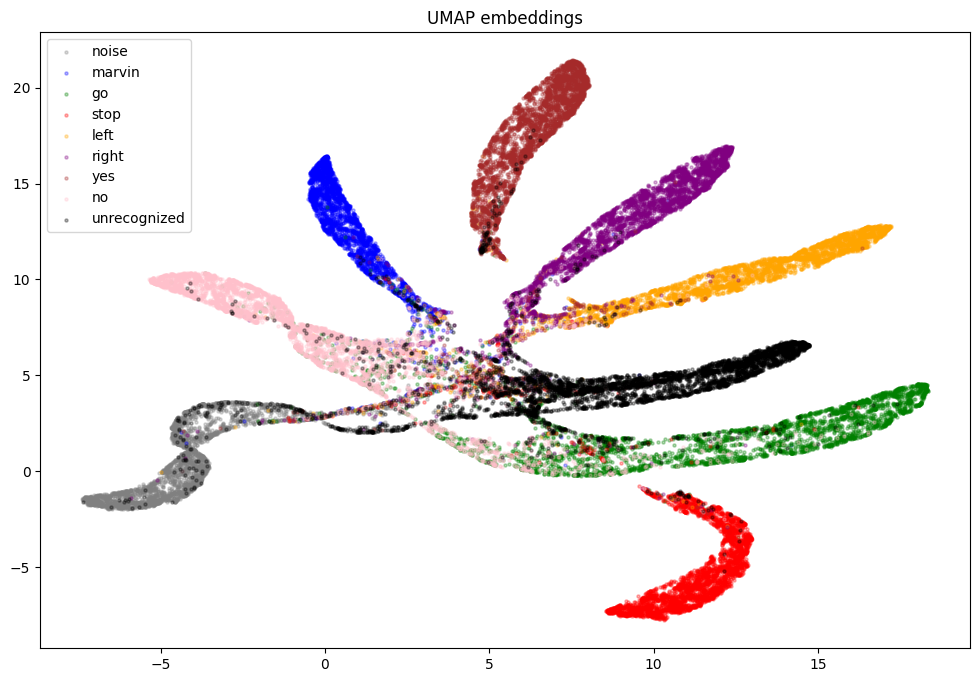

In [ ]:
plt.figure(figsize=(12, 8))
colors = np.array(['gray', 'blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'black'])
for label, name in enumerate(['noise', 'marvin', 'go', 'stop', 'left', 'right', 'yes', 'no', 'unrecognized']):
    mask = y_train == label
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                c=colors[label], label=name, alpha=0.3, s=5)

plt.legend()
plt.title('UMAP embeddings')
plt.show()

1117/1117 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
Encodings shape: (35730, 64)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


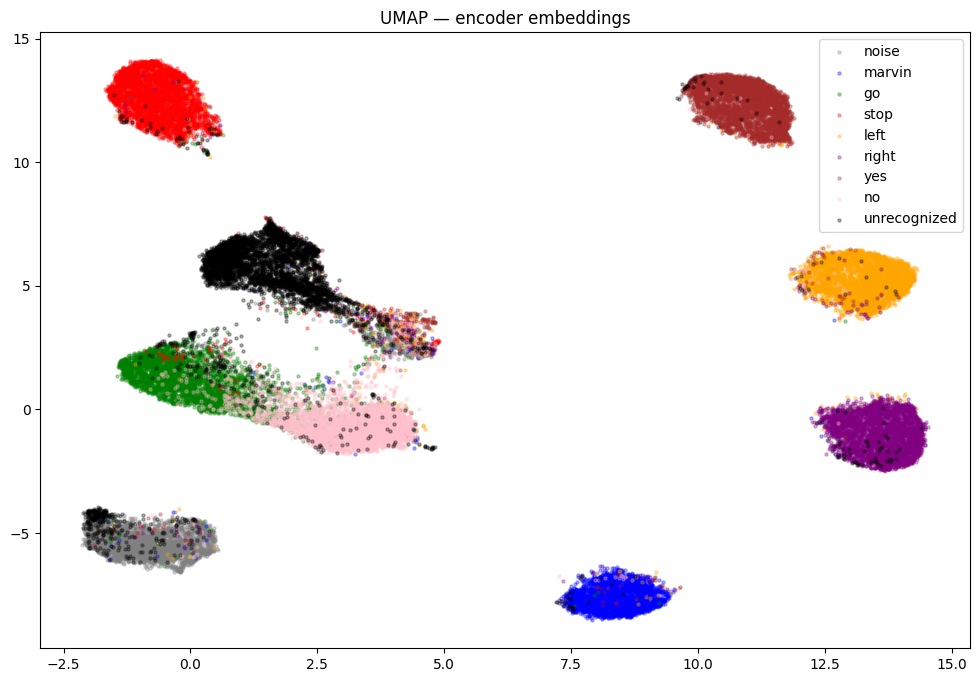

In [ ]:
# Будуємо encoder — відрізаємо softmax голову
encoder = models.Model(
    inputs=temp_model.input,
    outputs=temp_model.get_layer('embedding_output').output
)

# Отримуємо encodings
encodings_test = encoder.predict(X_train[..., np.newaxis])
print("Encodings shape:", encodings_test.shape)  # (n, 64)

# UMAP на encodings
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(encodings_test)

plt.figure(figsize=(12, 8))
colors = ['gray', 'blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'black']
for label, name in enumerate(['noise', 'marvin', 'go', 'stop', 'left', 'right', 'yes', 'no', 'unrecognized']):
    mask = y_train == label
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                c=colors[label], label=name, alpha=0.3, s=5)

plt.legend()
plt.title('UMAP — encoder embeddings')
plt.show()

In [ ]:
import numpy as np

def compute_centroids(model, x_train, y_train):
    # Отримуємо ембеддінги для всього тренувального набору
    print("Генерація ембеддінгів...")
    embeddings = encodings_test

    centroids = {}
    stds = {}

    for class_idx in range(9):  # Наші 9 класів (0-8)
        # Вибираємо ембеддінги лише цього класу
        class_embeddings = embeddings[y_train == class_idx]

        if len(class_embeddings) > 0:
            # Обчислюємо медіанний центроїд (по кожній осі ембеддінга)
            centroid = np.median(class_embeddings, axis=0)

            # Обчислюємо відстані від кожної точки класу до цього центроїда
            distances = np.linalg.norm(class_embeddings - centroid, axis=1)

            # Зберігаємо центроїд та середнє відхилення (std)
            centroids[class_idx] = centroid
            stds[class_idx] = np.std(distances)

            print(f"Клас {class_idx}: центроїд обчислено, STD відхилення: {stds[class_idx]:.4f}")

    return centroids, stds

# Використовуємо твою base_model (ту, що видає вектор 64 dim)
centroids, stds = compute_centroids(encoder, X_train, y_train)

# Збережемо їх, щоб гра могла використовувати їх без перерахунку
np.save('/content/drive/MyDrive/audio_for_game/centroids.npy', centroids)
np.save('/content/drive/MyDrive/audio_for_game/stds.npy', stds)

Генерація ембеддінгів...
Клас 0: центроїд обчислено, STD відхилення: 0.2085
Клас 1: центроїд обчислено, STD відхилення: 0.2233
Клас 2: центроїд обчислено, STD відхилення: 0.2234
Клас 3: центроїд обчислено, STD відхилення: 0.2569
Клас 4: центроїд обчислено, STD відхилення: 0.2435
Клас 5: центроїд обчислено, STD відхилення: 0.2389
Клас 6: центроїд обчислено, STD відхилення: 0.2571
Клас 7: центроїд обчислено, STD відхилення: 0.2264
Клас 8: центроїд обчислено, STD відхилення: 0.2442


In [ ]:
encoder.input.shape, X_test.shape

((None, 64, 128, 1), (6306, 64, 128))

Генерація ембеддінгів (Sigma Multiplier: 3)...
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Класифікація з урахуванням радіусів впевненості...

CLASSIFICATION REPORT (CENTROID + 3 SIGMA)
              precision    recall  f1-score   support

       noise       0.41      0.97      0.57       645
      marvin       0.99      0.91      0.95       524
          go       0.92      0.75      0.83       712
        stop       0.98      0.90      0.94       714
        left       0.98      0.79      0.88       706
       right       0.97      0.88      0.92       710
         yes       0.97      0.89      0.93       713
          no       0.92      0.78      0.84       713
unrecognized       0.94      0.63      0.76       869

    accuracy                           0.82      6306
   macro avg       0.90      0.83      0.85      6306
weighted avg       0.90      0.82      0.84      6306



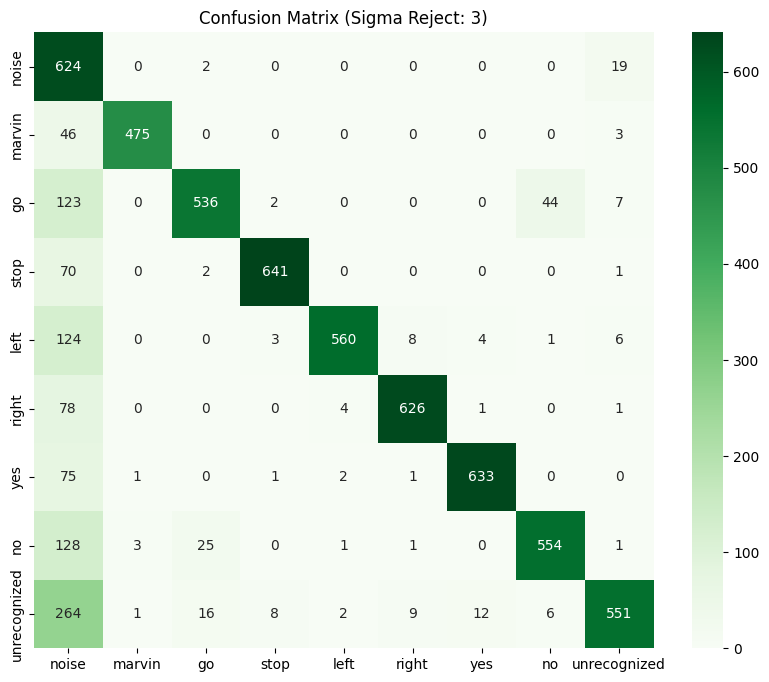

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test_centroid_classifier_with_sigma(model, x_test, y_test, centroids, stds, sigma_mult=2.0):
    print(f"Генерація ембеддінгів (Sigma Multiplier: {sigma_mult})...")

    # Корекція розмірності входу
    x_test_input = X_test[..., np.newaxis] if len(x_test.shape) == 3 else x_test

    # Отримання векторів
    test_embeddings = model.predict(x_test_input, batch_size=32)

    y_pred = []
    centroid_matrix = np.array([centroids[i] for i in range(9)])

    print("Класифікація з урахуванням радіусів впевненості...")
    for emb in test_embeddings:
        # Відстані до всіх центроїдів
        distances = np.linalg.norm(centroid_matrix - emb, axis=1)

        # Попередній найкращий клас
        best_class = np.argmin(distances)
        min_dist = distances[best_class]

        # --- ПЕРЕВІРКА НА ІНТЕРВАЛ ---
        # Якщо ми за межами 2 STD для цього класу — примусово маркуємо як noise (0)
        # Клас 0 сам по собі не перевіряється (або можна залишити як є)
        if best_class != 0 and min_dist > (stds[best_class] * sigma_mult):
            y_pred.append(0)
        else:
            y_pred.append(best_class)

    y_pred = np.array(y_pred)
    target_names = ['noise', 'marvin', 'go', 'stop', 'left', 'right', 'yes', 'no', 'unrecognized']

    print("\n" + "="*60)
    print(f"CLASSIFICATION REPORT (CENTROID + {sigma_mult} SIGMA)")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Greens')
    plt.title(f'Confusion Matrix (Sigma Reject: {sigma_mult})')
    plt.show()

# Запуск
test_centroid_classifier_with_sigma(encoder, X_test, y_test, centroids, stds, sigma_mult=3)

In [ ]:
import tensorflow as tf
import os

DRIVE_PATH = '/content/drive/MyDrive/audio_for_game'

# 1. Шлях для збереження
TFLITE_NAME = 'audio_encoder_v3.tflite'
save_path = os.path.join(DRIVE_PATH, TFLITE_NAME)

# 2. Створюємо конвертер для нашого енкодера (encoder)
# Використовуємо саме модель-енкодер, яка видає вектор 64 dim
converter = tf.lite.TFLiteConverter.from_keras_model(encoder)

# 3. Оптимізація (Quantization)
# Це зменшить розмір моделі в 4 рази (з float32 до int8/float16 всередині)
# майже без втрати точності.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Дозволяємо складні операції (якщо Lambda-шар потребує цього)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, # Стандартні операції
    tf.lite.OpsSet.SELECT_TF_OPS   # Додаткові операції TF
]

# 4. Конвертація
print("Починаємо конвертацію у TFLite... це може зайняти хвилину.")
tflite_model = converter.convert()

# 5. Запис у файл
with open(save_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Модель успішно збережена: {save_path}")
print(f"Розмір файлу: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")

Починаємо конвертацію у TFLite... це може зайняти хвилину.
Saved artifact at '/tmp/tmpgrwgfde6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 128, 1), dtype=tf.float32, name='keras_tensor_120')
Output Type:
  TensorSpec(shape=(None, 64), dtype=tf.float32, name=None)
Captures:
  135642334609872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332423824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651424685904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642939518480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332425168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332414992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332424208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332429584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332426512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135642332415568: Tens

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# --- Loss з collapse penalty ---
def pairwise_distances(embeddings):
    dot_product = tf.matmul(embeddings, tf.transpose(embeddings))
    sq_norm = tf.linalg.diag_part(dot_product)
    distances = tf.expand_dims(sq_norm, 0) - 2.0 * dot_product + tf.expand_dims(sq_norm, 1)
    distances = tf.maximum(distances, 0.0)
    distances = tf.sqrt(distances + 1e-12)
    return distances

def batch_hard_triplet_loss(labels, embeddings, margin=0.3):
    distances = pairwise_distances(embeddings)
    labels = tf.cast(labels, tf.int32)
    labels_eq = tf.equal(tf.expand_dims(labels, 0), tf.expand_dims(labels, 1))
    pos_mask = tf.cast(labels_eq, tf.float32)
    hardest_pos = tf.reduce_max(distances * pos_mask, axis=1)
    neg_mask = tf.cast(tf.logical_not(labels_eq), tf.float32)
    max_dist = tf.reduce_max(distances)
    hardest_neg = tf.reduce_min(distances + max_dist * (1.0 - neg_mask), axis=1)
    triplet_loss = tf.reduce_mean(tf.maximum(hardest_pos - hardest_neg + margin, 0.0))

    # Collapse penalty — м'який поріг
    variance = tf.reduce_mean(tf.math.reduce_variance(embeddings, axis=0))
    collapse_penalty = tf.maximum(0.05 - variance, 0.0) * 2.0

    return triplet_loss + collapse_penalty, variance

# --- Збалансований датасет ---
# Враховуємо 9 класів якщо є unrecognized
N_CLASSES = len(np.unique(y_train))
BATCH_SIZE = N_CLASSES * 16
SAMPLES_PER_CLASS = 16

def make_balanced_dataset(X, y):
    classes = np.unique(y)
    def generator():
        while True:
            batch_X, batch_y = [], []
            for cls in classes:
                idx = np.where(y == cls)[0]
                chosen = np.random.choice(idx, SAMPLES_PER_CLASS,
                                          replace=len(idx) < SAMPLES_PER_CLASS)
                batch_X.append(X[chosen])
                batch_y.append(y[chosen])
            batch_X = np.concatenate(batch_X).astype(np.float32)[..., np.newaxis]
            batch_y = np.concatenate(batch_y).astype(np.int32)
            perm = np.random.permutation(len(batch_X))
            yield batch_X[perm], batch_y[perm]

    return tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(BATCH_SIZE, 64, 128, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(BATCH_SIZE,), dtype=tf.int32)
        )
    )

# --- Encoder ---
encoder = models.Model(
    inputs=temp_model.input,
    outputs=temp_model.get_layer('embedding_output').output
)
for layer in encoder.layers:
    layer.trainable = True

# --- Моніторинг collapse ---
X_check = tf.constant(_train[:BATCH_SIZE][..., np.newaxis], dtype=tf.float32)

def check_variance():
    emb = encoder(X_check, training=False)
    return float(tf.reduce_mean(tf.math.reduce_variance(emb, axis=0)))

# --- Оптимізатор ---
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-6)

@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        embeddings = encoder(X_batch, training=True)
        loss, variance = batch_hard_triplet_loss(y_batch, embeddings, margin=0.3)
    grads = tape.gradient(loss, encoder.trainable_variables)
    optimizer.apply_gradients(zip(grads, encoder.trainable_variables))
    return loss, variance

# --- Тренування ---
STEPS_PER_EPOCH = 200
EPOCHS = 7
COLLAPSE_THRESHOLD = 0.01

train_ds = make_balanced_dataset(x_train, y_train)
ds_iter  = iter(train_ds)

initial_variance = check_variance()
print(f"Початкова variance: {initial_variance:.4f}")

best_variance = initial_variance
best_loss = float('inf')
collapsed = False

print("Починаємо triplet loss finetune...")
for epoch in range(EPOCHS):
    epoch_losses = []
    epoch_variances = []

    for step in range(STEPS_PER_EPOCH):
        X_batch, y_batch = next(ds_iter)
        loss, var = train_step(X_batch, y_batch)
        epoch_losses.append(float(loss))
        epoch_variances.append(float(var))

        # Моніторинг collapse кожні 20 кроків
        if step % 20 == 0:
            current_var = check_variance()
            if current_var < COLLAPSE_THRESHOLD:
                print(f"  COLLAPSE! variance={current_var:.4f} — зупиняємо")
                collapsed = True
                break

    if collapsed:
        break

    mean_loss = np.mean(epoch_losses)
    mean_var  = np.mean(epoch_variances)
    current_var = check_variance()

    print(f"Epoch {epoch+1}/{EPOCHS} — loss: {mean_loss:.4f}, variance: {current_var:.4f}")

    # Зберігаємо якщо variance стабільна і loss падає
    if mean_loss < best_loss and current_var > COLLAPSE_THRESHOLD * 2:
        best_loss = mean_loss
        best_variance = current_var
        encoder.save('/content/drive/MyDrive/audio_for_game/encoder_triplet.keras')
        print(f"  Збережено (loss: {best_loss:.4f}, variance: {best_variance:.4f})")

NameError: name 'x_train' is not defined

In [ ]:
# --- Classification report ---
from sklearn.metrics import classification_report
import numpy as np

results_triplet = []
probs_triplet = []
encodings_triplet = []

dummy = np.zeros((1, 64, 128, 1), dtype=np.float32)
_ = temp_model(dummy, training=False)

results_triplet = []
probs_triplet = []
encodings_triplet = []

for i in range(len(x_test)):
    inp = x_test[i][np.newaxis, :, :, np.newaxis].astype(np.float32)

    soft = temp_model(inp, training=False).numpy()[0]
    results_triplet.append(np.argmax(soft))
    probs_triplet.append(soft)

    enc = encoder(inp, training=False).numpy()[0]
    encodings_triplet.append(enc)

results_triplet   = np.array(results_triplet)
probs_triplet     = np.array(probs_triplet)
encodings_triplet = np.array(encodings_triplet)

# Cosine confidence з порогами
results_cosine_triplet = []
for i in range(len(x_test)):
    pred_class = results_triplet[i]
    cos_conf   = cosine_confidence(probs_triplet[i])
    threshold  = thresholds_cosine.get(pred_class, 0.45)
    results_cosine_triplet.append(pred_class if cos_conf >= threshold else 0)

results_cosine_triplet = np.array(results_cosine_triplet)

names_full = ['noise', 'marvin', 'go', 'stop', 'left', 'right', 'yes', 'no', 'unrecognized']
print(classification_report(y_test, results_cosine_triplet, target_names=names_full))

KeyboardInterrupt: 

In [ ]:
# --- UMAP encoder embeddings ---
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(encodings_triplet)

colors = ['gray', 'blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'black']

plt.figure(figsize=(12, 8))
for label, name in enumerate(names_full):
    mask = y_test == label
    if mask.sum() == 0:
        continue
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                c=colors[label], label=name, alpha=0.3, s=5)

plt.legend()
plt.title('UMAP — encoder після triplet loss')
plt.show()